# ATLAS Hydro Scenario Visualization

This notebook creates the final maps for future river discharge scenarios.

It uses the monthly outputs generated by the **scenario change analysis** notebook and produces maps for:

1. future river discharge, in `m³/s`
2. change relative to the present baseline, normally in `%`
3. optional detailed maps for one selected level 5 basin

The notebook is organised step by step so that it can be shared with users who are not expert Python users.


## Step 1. Import Python libraries

Run this cell first. If an import fails, install the missing package in the Python environment before continuing.


In [1]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs


ERROR 1: PROJ: proj_create_from_database: Open of /home/alessandrom/anaconda3/envs/bias_correction_conda/share/proj failed


## Step 2. Define user parameters

Edit only this cell when changing country, model, scenario, period or folders.

The expected scenario input folder is the one produced by the previous notebook:

`../data/scenarios/river_discharge/{COUNTRY_FOLDER}/{SCENARIO_EXPERIMENT}/{MODEL}/{SCENARIO_START}_{SCENARIO_END}/`

The figures are saved in:

`../figures/hydro_scenarios/{COUNTRY_FOLDER}/{SCENARIO_EXPERIMENT}/{MODEL}/{SCENARIO_START}_{SCENARIO_END}/`


In [9]:
# ---------------------------------------------------------------------
# Main configuration
# ---------------------------------------------------------------------

COUNTRY_FOLDER = "ecuador"
COUNTRY_NAME_IN_SHAPEFILE = "Ecuador"

VARIABLE_LONG_NAME = "river_discharge"
MODEL = "CNRM-ESM2-1"
SCENARIO_EXPERIMENT = "ssp370"
SCENARIO_START = "2020"
SCENARIO_END = "2050"

# Set ANNUAL_PLOT = True to plot the annual mean computed from the 12 monthly files.
# Set ANNUAL_PLOT = False to plot only the month selected below.
ANNUAL_PLOT = False
MONTH = 1

# Optional detailed basin plot.
# Select a row number from the level 5 basin table.
SELECTED_L5_BASIN_INDEX = 10

# Ecuador needs an inset for the Galápagos Islands.
ADD_GALAPAGOS_INSET = COUNTRY_FOLDER.lower() == "ecuador"

# ---------------------------------------------------------------------
# Input and output folders
# ---------------------------------------------------------------------

SCENARIO_INPUT_DIR = (
    Path("../data/atlas_data")
    / COUNTRY_FOLDER
    / MODEL
    / SCENARIO_EXPERIMENT
)

FIGURE_OUTPUT_DIR = (
    Path("../data/figures")
    / COUNTRY_FOLDER
    / MODEL
    / SCENARIO_EXPERIMENT
)

FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Static geospatial inputs.
SHAPEFILE_PATH = Path("../world_map/ne_50m_admin_0_countries.shp")
HYDRO_RIVERS_PATH = Path("../hydrorivers/HydroRIVERS_v10_sa_shp/HydroRIVERS_v10_sa.shp")
HYDROBASINS_DIR = Path("../hydrobasins")

print("Country folder:", COUNTRY_FOLDER)
print("Country name in shapefile:", COUNTRY_NAME_IN_SHAPEFILE)
print("Scenario input folder:", SCENARIO_INPUT_DIR)
print("Figure output folder:", FIGURE_OUTPUT_DIR)


Country folder: ecuador
Country name in shapefile: Ecuador
Scenario input folder: ../data/atlas_data/ecuador/CNRM-ESM2-1/ssp370
Figure output folder: ../data/figures/ecuador/CNRM-ESM2-1/ssp370


## Step 3. Define helper functions

These functions read the scenario outputs, load the static hydrological layers and make the maps.


In [4]:
def check_file_exists(path):
    """Stop the notebook with a clear message if a required file does not exist."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")
    return path


def read_country_geometry(shapefile_path, country_name):
    """Read the selected country boundary from the Natural Earth shapefile."""
    shapefile_path = check_file_exists(shapefile_path)
    countries = gpd.read_file(shapefile_path)[["ADMIN", "geometry"]]
    countries = countries.set_index("ADMIN")

    if countries.crs is None:
        countries = countries.set_crs("EPSG:4326")
    countries = countries.to_crs("EPSG:4326")

    if country_name not in countries.index:
        available = ", ".join(countries.index[:10])
        raise ValueError(
            f"Country '{country_name}' was not found in {shapefile_path}. "
            f"Examples of available names: {available} ..."
        )

    return countries.loc[[country_name]]


def read_hydrorivers(rivers_path, country_boundary):
    """Read HydroRIVERS and clip it to the selected country."""
    rivers_path = check_file_exists(rivers_path)
    rivers = gpd.read_file(rivers_path)

    if rivers.crs is None:
        rivers = rivers.set_crs("EPSG:4326")
    rivers = rivers.to_crs("EPSG:4326")

    country_rivers = gpd.clip(rivers, country_boundary.geometry)
    return country_rivers


def read_hydrobasins(level, hydrobasins_dir, country_boundary):
    """Read HydroBASINS at the selected level and clip it to the selected country."""
    level_string = str(level).zfill(2)
    basin_file = Path(hydrobasins_dir) / f"hybas_lake_sa_lev{level_string}_v1c.shp"
    basin_file = check_file_exists(basin_file)

    basins = gpd.read_file(basin_file)
    if basins.crs is None:
        basins = basins.set_crs("EPSG:4326")
    basins = basins.to_crs("EPSG:4326")

    lakes = basins[basins["LAKE"] == 1].copy()
    basins = basins[basins["LAKE"] == 0].copy()

    country_basins = gpd.clip(basins, country_boundary.geometry)
    country_lakes = gpd.clip(lakes, country_boundary.geometry)

    if int(level) == 12:
        country_basins["L5basin"] = country_basins["PFAF_ID"].astype(str).str[:5].astype(int)

    return country_basins, country_lakes


def read_geodataframe_from_csv(csv_file):
    """Read a CSV produced by the scenario notebook and convert WKT geometry to GeoDataFrame."""
    csv_file = check_file_exists(csv_file)
    df = pd.read_csv(csv_file)

    if "Unnamed: 0" in df.columns:
        df = df.drop(columns="Unnamed: 0")

    if "geometry" not in df.columns:
        raise KeyError(
            f"The file {csv_file} does not contain a 'geometry' column. "
            "Re-run the previous scenario notebook ensuring that geometry is saved as WKT."
        )

    df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
    gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
    return gdf


def scenario_file(level, month):
    """Build the expected scenario file path for one HydroBASINS level and one month."""
    level = int(level)
    if level == 5:
        geojson_file = SCENARIO_INPUT_DIR / (
            f"river_discharge_l5_{COUNTRY_FOLDER}_m{month}_"
            f"{SCENARIO_EXPERIMENT}_{SCENARIO_START}_{SCENARIO_END}.geojson"
        )
        csv_file = SCENARIO_INPUT_DIR / (
            f"river_discharge_l5_{COUNTRY_FOLDER}_m{month}_"
            f"{SCENARIO_EXPERIMENT}_{SCENARIO_START}_{SCENARIO_END}.csv"
        )
        if geojson_file.exists():
            return geojson_file
        return csv_file

    if level == 12:
        return SCENARIO_INPUT_DIR / (
            f"river_discharge_l12_{COUNTRY_FOLDER}_m{month}_"
            f"{SCENARIO_EXPERIMENT}_{SCENARIO_START}_{SCENARIO_END}.csv"
        )

    raise ValueError("Only levels 5 and 12 are supported.")


def read_monthly_scenario_data(level, month):
    """Read one monthly scenario file for level 5 or level 12."""
    file_path = scenario_file(level=level, month=month)

    if file_path.suffix.lower() == ".geojson":
        file_path = check_file_exists(file_path)
        gdf = gpd.read_file(file_path)
        if gdf.crs is None:
            gdf = gdf.set_crs("EPSG:4326")
        return gdf.to_crs("EPSG:4326")

    return read_geodataframe_from_csv(file_path)


def read_annual_scenario_data(level):
    """Read all monthly files and compute annual means for numeric scenario columns."""
    monthly_gdfs = [read_monthly_scenario_data(level=level, month=month) for month in range(1, 13)]
    annual_gdf = monthly_gdfs[0].copy()

    candidate_columns = [
        "mean_river_discharge_corrected",
        "delta_river_discharge",
        "mean_river_discharge_integrated",
        "mean_river_discharge",
    ]

    for column in candidate_columns:
        if all(column in gdf.columns for gdf in monthly_gdfs):
            annual_gdf[column] = pd.concat([gdf[column] for gdf in monthly_gdfs], axis=1).mean(axis=1)

    return annual_gdf


def load_scenario_data(level):
    """Load either the annual mean or one selected month depending on ANNUAL_PLOT."""
    if ANNUAL_PLOT:
        return read_annual_scenario_data(level=level)
    return read_monthly_scenario_data(level=level, month=MONTH)


def get_period_label():
    """Return a readable label for titles and filenames."""
    if ANNUAL_PLOT:
        return f"annual mean, {SCENARIO_EXPERIMENT}, {SCENARIO_START}-{SCENARIO_END}"
    month_name = MONTH_NAMES[MONTH - 1]
    return f"{month_name}, {SCENARIO_EXPERIMENT}, {SCENARIO_START}-{SCENARIO_END}"


def get_filename_period_label():
    """Return a compact label for output filenames."""
    if ANNUAL_PLOT:
        return f"annual_{SCENARIO_EXPERIMENT}_{SCENARIO_START}_{SCENARIO_END}"
    return f"m{MONTH}_{SCENARIO_EXPERIMENT}_{SCENARIO_START}_{SCENARIO_END}"


## Step 4. Load country boundary, rivers, basins and lakes

These layers are used only for plotting and for the optional detailed basin map.


In [5]:
country_boundary = read_country_geometry(
    shapefile_path=SHAPEFILE_PATH,
    country_name=COUNTRY_NAME_IN_SHAPEFILE,
)

country_rivers = read_hydrorivers(
    rivers_path=HYDRO_RIVERS_PATH,
    country_boundary=country_boundary,
)

# Keep only the main rivers for a cleaner map.
rivers_only = country_rivers[country_rivers["ORD_FLOW"] < 7].copy()

country_basins_l5, country_lakes_l5 = read_hydrobasins(
    level=5,
    hydrobasins_dir=HYDROBASINS_DIR,
    country_boundary=country_boundary,
)

country_basins_l12, country_lakes_l12 = read_hydrobasins(
    level=12,
    hydrobasins_dir=HYDROBASINS_DIR,
    country_boundary=country_boundary,
)

print("Level 5 basins:", len(country_basins_l5))
print("Level 12 basins:", len(country_basins_l12))
print("Rivers:", len(rivers_only))


Level 5 basins: 11
Level 12 basins: 2110
Rivers: 15287


## Step 5. Load scenario data

The notebook loads level 5 and level 12 scenario outputs from the previous workflow step.


In [10]:
MONTH_NAMES = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]

scenario_l5 = load_scenario_data(level=5)
scenario_l12 = load_scenario_data(level=12)

print("Level 5 scenario data:")
print(scenario_l5.head())
print("Level 12 scenario data:")
print(scenario_l12.head())
print("Available columns:")
print(scenario_l12.columns.tolist())


Level 5 scenario data:
     HYBAS_ID   NEXT_DOWN   NEXT_SINK    MAIN_BAS  DIST_SINK  DIST_MAIN  \
0  6050315910  6050266740  6050007000  6050007000     3493.7     3493.7   
1  6050032100           0  6050032100  6050032100        0.0        0.0   
2  6050032110           0  6050032110  6050032110        0.0        0.0   
3  6050032290           0  6050032290  6050032290        0.0        0.0   
4  6050266740  6050287820  6050007000  6050007000     2156.8     2156.8   

   SUB_AREA    UP_AREA  PFAF_ID SIDE  LAKE  ENDO  COAST  ORDER  SORT  \
0  364869.2   364873.4    62298    M     0     0      0      2   178   
1   17761.9    17761.9    67108    M     0     0      0      1   516   
2   11236.5    11236.5    67109    M     0     0      1      0   517   
3   16478.7    16478.7    67201    M     0     0      1      0   518   
4  514725.6  1233304.8    62297    M     0     0      0      1   165   

   mean_river_discharge_corrected  delta_river_discharge  \
0                       55.165776

## Step 6. Define plotting functions

The function below is used for both level 5 and level 12 maps.

For Ecuador, it adds a Galápagos inset using the same logic adopted in the station integration and maps notebook. The inset position is defined relative to the main map axis, so it remains stable even when the figure layout changes.

The parameter `galapagos_inset_position` uses the format `(left, bottom, width, height)`, where each value is a fraction of the main map axis.


In [11]:
def add_galapagos_inset(
    fig,
    main_ax,
    basins_gdf,
    value_column,
    norm,
    cmap,
    relative_position=(0.18, 0.22, 0.25, 0.22),
):
    """Add a Galápagos inset to an Ecuador map.

    The inset position is defined relative to the main map axis, following the
    same approach used in the station integration and maps notebook.

    relative_position = (left, bottom, width, height)
    where all values are fractions of the main axis size.
    """
    main_pos = main_ax.get_position()

    relative_left, relative_bottom, relative_width, relative_height = relative_position

    inset_left = main_pos.x0 + main_pos.width * relative_left
    inset_bottom = main_pos.y0 + main_pos.height * relative_bottom
    inset_width = main_pos.width * relative_width
    inset_height = main_pos.height * relative_height

    inset_ax = fig.add_axes(
        [inset_left, inset_bottom, inset_width, inset_height],
        projection=ccrs.PlateCarree(),
    )

    basins_gdf.plot(
        column=value_column,
        ax=inset_ax,
        cmap=cmap,
        legend=False,
        norm=norm,
        edgecolor="k",
        linewidth=0.4,
    )

    inset_ax.coastlines(linewidth=0.4)
    inset_ax.set_extent([-92.2, -89.0, -1.7, 0.8], crs=ccrs.PlateCarree())
    inset_ax.set_title("Galápagos", fontsize=12)

    inset_ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.3,
        color="black",
        alpha=0.4,
        linestyle="--",
    )

    return inset_ax


def plot_scenario_map(
    basins_gdf,
    value_column,
    rivers_gdf,
    lakes_gdf,
    title,
    output_file,
    cmap,
    norm,
    ticks,
    colorbar_label,
    country_boundary,
    add_inset=False,
    galapagos_inset_position=(0.18, 0.22, 0.25, 0.22),
):
    """Create and save one river discharge scenario map."""
    if value_column not in basins_gdf.columns:
        raise KeyError(
            f"Column '{value_column}' was not found. Available columns are: "
            f"{basins_gdf.columns.tolist()}"
        )

    output_file = Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(12, 10),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )

    basins_gdf.plot(
        column=value_column,
        ax=ax,
        cmap=cmap,
        legend=False,
        norm=norm,
        edgecolor="k",
        linewidth=0.5,
    )

    main_rivers = rivers_gdf[rivers_gdf["ORD_FLOW"] < 6].copy()
    if len(main_rivers) > 0:
        main_rivers.plot(
            ax=ax,
            color="orange",
            linewidth=3 / main_rivers["ORD_FLOW"],
        )

    if len(lakes_gdf) > 0:
        lakes_gdf.plot(ax=ax, facecolor="green", edgecolor="none", zorder=10)

    ax.coastlines(linewidth=0.5)

    minx, miny, maxx, maxy = country_boundary.total_bounds
    padding_x = (maxx - minx) * 0.05
    padding_y = (maxy - miny) * 0.05
    ax.set_extent(
        [minx - padding_x, maxx + padding_x, miny - padding_y, maxy + padding_y],
        crs=ccrs.PlateCarree(),
    )

    ax.set_title(title, fontsize=20)

    gridlines = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color="black",
        alpha=0.5,
        linestyle="--",
    )
    gridlines.top_labels = False
    gridlines.right_labels = False
    gridlines.xlabel_style = {"size": 12}
    gridlines.ylabel_style = {"size": 12}

    if add_inset:
        add_galapagos_inset(
            fig=fig,
            main_ax=ax,
            basins_gdf=basins_gdf,
            value_column=value_column,
            norm=norm,
            cmap=cmap,
            relative_position=galapagos_inset_position,
        )

    colorbar_object = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    colorbar = fig.colorbar(
        colorbar_object,
        ax=ax,
        orientation="vertical",
        aspect=25,
        shrink=0.75,
    )
    colorbar.set_ticks(ticks)
    colorbar.set_ticklabels(ticks)
    colorbar.set_label(colorbar_label, size=14)
    colorbar.ax.tick_params(labelsize=12)

    plt.savefig(output_file, dpi=150, bbox_inches="tight")
    plt.close(fig)

    print("Saved figure:", output_file)
    return fig

## Step 7. Plot future river discharge maps

These maps show the absolute future river discharge values.

The expected column is `mean_river_discharge_corrected`, which is produced by the scenario change analysis notebook.


Saved figure: ../data/figures/ecuador/CNRM-ESM2-1/ssp370/river_discharge_l5_ecuador_m1_ssp370_2020_2050.png
Saved figure: ../data/figures/ecuador/CNRM-ESM2-1/ssp370/river_discharge_l12_ecuador_m1_ssp370_2020_2050.png


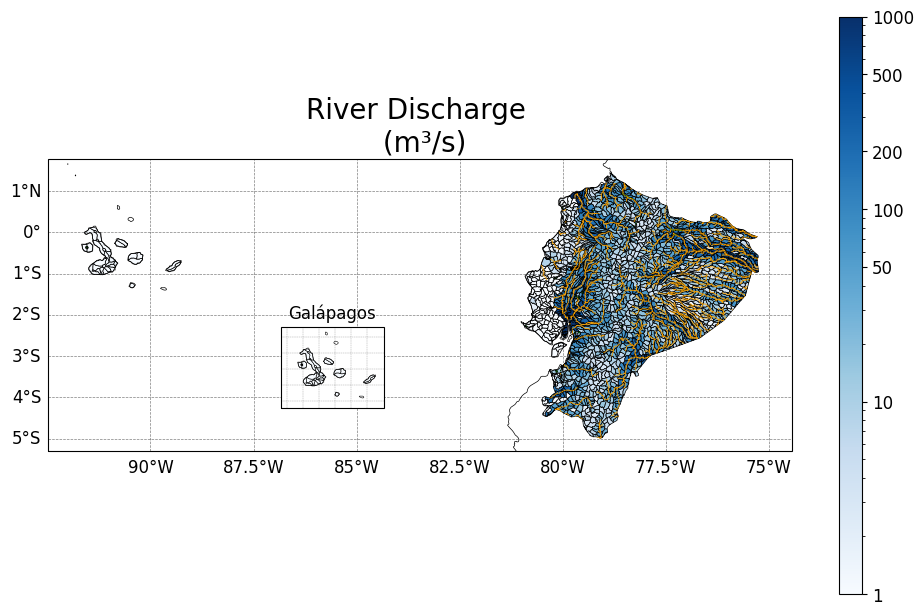

In [14]:
DISCHARGE_COLUMN = "mean_river_discharge_corrected"

# Values equal to zero or negative cannot be shown with a logarithmic scale.
# They are replaced by 1 only for visualization.
for gdf in [scenario_l5, scenario_l12]:
    if DISCHARGE_COLUMN in gdf.columns:
        gdf[DISCHARGE_COLUMN] = gdf[DISCHARGE_COLUMN].where(gdf[DISCHARGE_COLUMN] > 1, 1)

period_label = get_period_label()
filename_period_label = get_filename_period_label()

discharge_norm = colors.LogNorm(vmin=1, vmax=1000)
discharge_ticks = [1, 10, 50, 100, 200, 500, 1000]

plot_scenario_map(
    basins_gdf=scenario_l5,
    value_column=DISCHARGE_COLUMN,
    rivers_gdf=rivers_only,
    lakes_gdf=country_lakes_l5,
    title=f"River Discharge \n (m³/s)",
    output_file=FIGURE_OUTPUT_DIR / f"river_discharge_l5_{COUNTRY_FOLDER}_{filename_period_label}.png",
    cmap="Blues",
    norm=discharge_norm,
    ticks=discharge_ticks,
    colorbar_label="",
    country_boundary=country_boundary,
    add_inset=ADD_GALAPAGOS_INSET,
)

plot_scenario_map(
    basins_gdf=scenario_l12,
    value_column=DISCHARGE_COLUMN,
    rivers_gdf=rivers_only,
    lakes_gdf=country_lakes_l12,
    title=f"River Discharge \n (m³/s)",
    output_file=FIGURE_OUTPUT_DIR / f"river_discharge_l12_{COUNTRY_FOLDER}_{filename_period_label}.png",
    cmap="Blues",
    norm=discharge_norm,
    ticks=discharge_ticks,
    colorbar_label="",
    country_boundary=country_boundary,
    add_inset=ADD_GALAPAGOS_INSET,
)


## Step 8. Plot river discharge change maps

These maps show the change relative to the present baseline.

The expected column is `delta_river_discharge`. In the previous notebook this normally represents a percentage change.


Saved figure: ../data/figures/ecuador/CNRM-ESM2-1/ssp370/river_discharge_change_l5_ecuador_m1_ssp370_2020_2050.png
Saved figure: ../data/figures/ecuador/CNRM-ESM2-1/ssp370/river_discharge_change_l12_ecuador_m1_ssp370_2020_2050.png


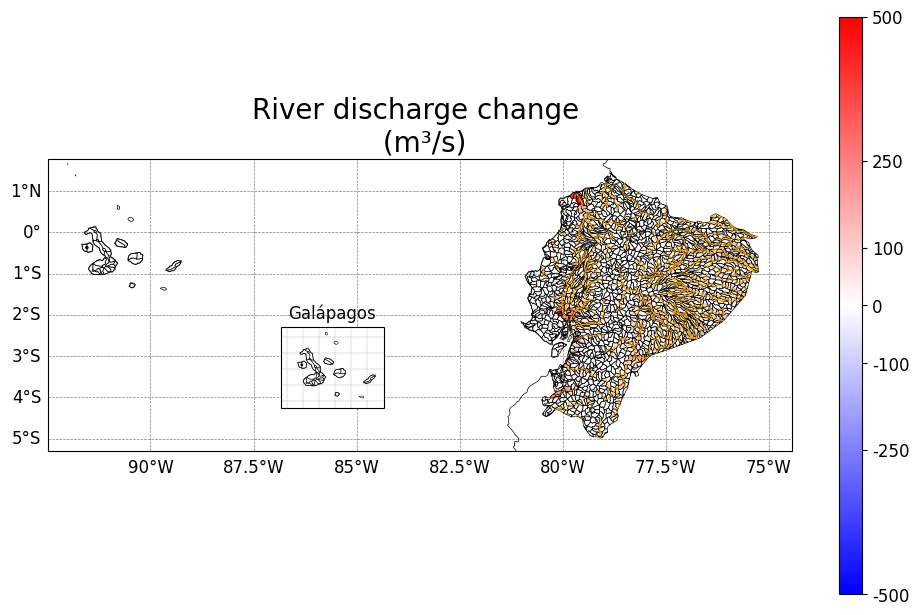

In [16]:
DELTA_COLUMN = "delta_river_discharge"

# Use a diverging scale centred on zero.
# Adjust these limits if your scenario produces changes outside this range.
delta_norm_l5 = colors.Normalize(vmin=-100, vmax=100)
delta_ticks_l5 = [-100, -50, 0, 50, 100]

delta_norm_l12 = colors.Normalize(vmin=-500, vmax=500)
delta_ticks_l12 = [-500, -250, -100, 0, 100, 250, 500]

plot_scenario_map(
    basins_gdf=scenario_l5,
    value_column=DELTA_COLUMN,
    rivers_gdf=rivers_only,
    lakes_gdf=country_lakes_l5,
    title=f"River discharge change \n (m³/s)",
    output_file=FIGURE_OUTPUT_DIR / f"river_discharge_change_l5_{COUNTRY_FOLDER}_{filename_period_label}.png",
    cmap="bwr",
    norm=delta_norm_l5,
    ticks=delta_ticks_l5,
    colorbar_label="",
    country_boundary=country_boundary,
    add_inset=ADD_GALAPAGOS_INSET,
)

plot_scenario_map(
    basins_gdf=scenario_l12,
    value_column=DELTA_COLUMN,
    rivers_gdf=rivers_only,
    lakes_gdf=country_lakes_l12,
    title=f"River discharge change \n (m³/s)",
    output_file=FIGURE_OUTPUT_DIR / f"river_discharge_change_l12_{COUNTRY_FOLDER}_{filename_period_label}.png",
    cmap="bwr",
    norm=delta_norm_l12,
    ticks=delta_ticks_l12,
    colorbar_label="",
    country_boundary=country_boundary,
    add_inset=ADD_GALAPAGOS_INSET,
)


## Step 9. Optional detailed map for one level 5 basin

This section selects one level 5 basin and plots only the level 12 sub-basins inside it.

Change `SELECTED_L5_BASIN_INDEX` in the configuration cell to select a different basin.


In [ ]:
def plot_selected_basin_map(
    scenario_l12,
    country_basins_l5,
    country_basins_l12,
    rivers_gdf,
    lakes_gdf,
    selected_l5_basin_index,
    value_column,
    title,
    output_file,
    cmap,
    norm,
    ticks,
    colorbar_label,
):
    """Plot level 12 scenario data inside one selected level 5 basin."""
    selected_l5_basin = gpd.GeoDataFrame(
        country_basins_l5.iloc[[selected_l5_basin_index]],
        geometry="geometry",
        crs=country_basins_l5.crs,
    )

    selected_l5_id = int(selected_l5_basin["PFAF_ID"].iloc[0])

    scenario_l12 = scenario_l12.copy()
    if "L5basin" not in scenario_l12.columns:
        scenario_l12["L5basin"] = scenario_l12["PFAF_ID"].astype(str).str[:5].astype(int)

    selected_scenario_l12 = scenario_l12[scenario_l12["L5basin"] == selected_l5_id].copy()
    selected_rivers = gpd.clip(rivers_gdf, selected_l5_basin)
    selected_lakes = gpd.clip(lakes_gdf, selected_l5_basin)

    basin_bounds = selected_l5_basin.total_bounds

    output_file = Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8, 8),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )

    selected_scenario_l12.plot(
        column=value_column,
        ax=ax,
        cmap=cmap,
        legend=False,
        norm=norm,
        edgecolor="k",
        linewidth=0.5,
    )

    if len(selected_rivers) > 0:
        selected_rivers.plot(
            ax=ax,
            color="orange",
            linewidth=2 / selected_rivers["ORD_FLOW"],
        )

    if len(selected_lakes) > 0:
        selected_lakes.plot(ax=ax, facecolor="green", edgecolor="none", zorder=10)

    ax.coastlines(linewidth=0.5)
    ax.set_extent(
        [basin_bounds[0], basin_bounds[2], basin_bounds[1], basin_bounds[3]],
        crs=ccrs.PlateCarree(),
    )
    ax.set_title(title, fontsize=15)

    gridlines = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color="black",
        alpha=0.5,
        linestyle="--",
    )
    gridlines.top_labels = False
    gridlines.right_labels = False

    colorbar_object = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    colorbar = fig.colorbar(colorbar_object, ax=ax, orientation="vertical", shrink=0.7)
    colorbar.set_ticks(ticks)
    colorbar.set_ticklabels(ticks)
    colorbar.set_label(colorbar_label, size=12)

    plt.savefig(output_file, dpi=150, bbox_inches="tight")
    plt.close(fig)

    print("Saved figure:", output_file)
    return fig


In [ ]:
# Detailed absolute discharge map.
selected_discharge_max = max(float(scenario_l12[DISCHARGE_COLUMN].max()), 10)
selected_discharge_norm = colors.LogNorm(vmin=1, vmax=selected_discharge_max)
selected_discharge_ticks = [1, 10, 50, 100, 500, 1000]
selected_discharge_ticks = [tick for tick in selected_discharge_ticks if tick <= selected_discharge_max]

plot_selected_basin_map(
    scenario_l12=scenario_l12,
    country_basins_l5=country_basins_l5,
    country_basins_l12=country_basins_l12,
    rivers_gdf=rivers_only,
    lakes_gdf=country_lakes_l12,
    selected_l5_basin_index=SELECTED_L5_BASIN_INDEX,
    value_column=DISCHARGE_COLUMN,
    title=f"River discharge \n (m³/s)",
    output_file=FIGURE_OUTPUT_DIR / f"selected_basin_river_discharge_{COUNTRY_FOLDER}_{filename_period_label}.png",
    cmap="Blues",
    norm=selected_discharge_norm,
    ticks=selected_discharge_ticks,
    colorbar_label="",
)

# Detailed change map.
selected_delta_absmax = float(np.nanmax(np.abs(scenario_l12[DELTA_COLUMN])))
selected_delta_absmax = max(selected_delta_absmax, 1)
selected_delta_norm = colors.Normalize(vmin=-selected_delta_absmax, vmax=selected_delta_absmax)
selected_delta_ticks = [
    -selected_delta_absmax,
    -selected_delta_absmax / 2,
    0,
    selected_delta_absmax / 2,
    selected_delta_absmax,
]

plot_selected_basin_map(
    scenario_l12=scenario_l12,
    country_basins_l5=country_basins_l5,
    country_basins_l12=country_basins_l12,
    rivers_gdf=rivers_only,
    lakes_gdf=country_lakes_l12,
    selected_l5_basin_index=SELECTED_L5_BASIN_INDEX,
    value_column=DELTA_COLUMN,
    title=f"River discharge change \n (m³/s)",
    output_file=FIGURE_OUTPUT_DIR / f"selected_basin_river_discharge_change_{COUNTRY_FOLDER}_{filename_period_label}.png",
    cmap="bwr",
    norm=selected_delta_norm,
    ticks=selected_delta_ticks,
    colorbar_label="",
)


## Step 10. Check generated figures

The final cell lists the figures saved by the notebook.


In [ ]:
figure_files = sorted(FIGURE_OUTPUT_DIR.glob("*.png"))

print(f"Number of figures saved: {len(figure_files)}")
for figure_file in figure_files:
    print(figure_file)
